# Flow of a Darcy fluid in an annulus

$$
\mathbb{S}_p
\begin{cases}
\Omega = \{(x, y)~:~R_{\text{inner}}^2 < x^2 + y^2 < R_{\text{outer}}^2\} \\
\partial\Omega_{\text{inner}} = \{(x, y)~:~ x^2 + y^2 = R_{\text{inner}}^2 \} \\
\partial\Omega_{\text{outer}} = \{(x, y)~:~ x^2 + y^2 = R_{\text{outer}}^2 \} \\
\mathsf{K}(x,y)=1 + \epsilon\sin\left(n\tan^{-1}(y/x)\right) \\
\mu=1 \\
p_{\text{D}}\vert_{\partial\Omega_{\text{inner}}}=p_{\text{in}} \\
p_{\text{D}}\vert_{\partial\Omega_{\text{outer}}}=0 \\
\end{cases}
$$

In [ ]:
import numpy as np
from lucifex.fem import Function, Constant
from lucifex.mesh import annulus_mesh, mesh_boundary
from lucifex.solver import BoundaryConditions, bvp, interpolation
from lucifex.viz import plot_contours, plot_mesh, plot_colormap, plot_quiver, save_figure
from lucifex.pde.darcy import darcy_pressure, darcy_velocity_from_pressure
from lucifex.pde.streamfunction_vorticity import streamfunction_from_velocity

Rinner = 0.1
Router = 1.0
Nradial = 30
dr = (Router - Rinner) / Nradial
mesh = annulus_mesh(dr, 'triangle')(Rinner, Router)

r2 = lambda x: x[0]**2 + x[1]**2
theta = lambda x: np.arctan2(x[1], x[0])
boundary = mesh_boundary(
    mesh, 
    {
        "inner": lambda x: r2(x) - Rinner**2,
        "outer": lambda x: r2(x) - Router**2,
    },
)

mu = Constant(mesh, 1.0)
eps = 0.25
n = 8
kx = lambda x: 1 + eps * np.cos(n * theta(x))
k = Function((mesh, 'P', 1), kx)

p_in = 1.0
p_bcs = BoundaryConditions(
    ("dirichlet", boundary['inner'], p_in),
    ("dirichlet", boundary['outer'], 0.0),  
)

p = Function((mesh, 'P', 2), name='p')
p_solver = bvp(darcy_pressure, p_bcs)(p, k, mu)

u = Function((mesh, 'P', 1, 2), name='u')
u_solver = interpolation(u, darcy_velocity_from_pressure)(p, k, mu)

psi = Function((mesh, 'P', 1), name='p')
psi_solver = bvp(streamfunction_from_velocity)(psi, u)

p_solver.solve()
u_solver.solve()
psi_solver.solve()

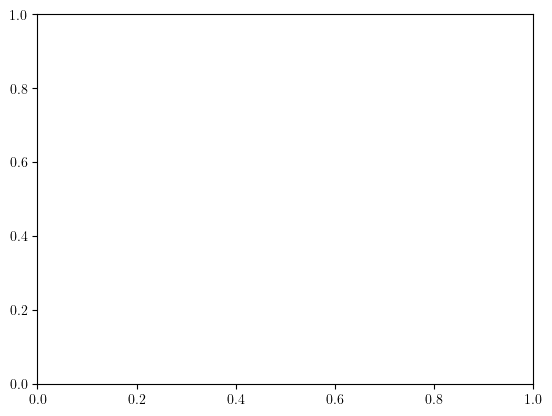

In [ ]:
from lucifex.utils import triangulation, get_component_fem_functions
import matplotlib.pyplot as plt

fx, fy = get_component_fem_functions(('P', 1), u)

trigl = triangulation(use_cache=True)(mesh)
xtri = trigl.x[trigl.triangles]
ytri = trigl.y[trigl.triangles]

fx_np = triangulation(use_cache=True)(fx)
fy_np = triangulation(use_cache=True)(fy)

fig, ax = plt.subplots()
# ax.quiver(
#     xtri,
#     ytri,
#     fx_np,
#     fy_np,
# )

In [6]:
print(np.shape(xtri))
print(np.shape(fx_np))
print(np.shape(ytri))
print(np.shape(fy_np))

(8149, 3)
(4190,)
(8149, 3)
(4190,)


In [ ]:
fig, ax = plot_colormap(k, title='$K$', x_label='$x$', y_label='$y$')
plot_mesh(fig, ax, mesh, color='cyan', linewidth=0.5)
# save_figure('K(x,y)_mesh')(fig)

fig, ax = plot_colormap(p, title='$p$', x_label='$x$', y_label='$y$')
plot_contours(fig, ax, psi, colors='cyan', levels=20)

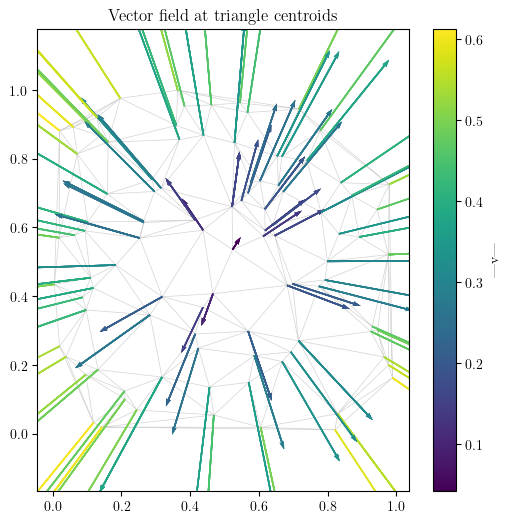

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri

# --- Triangular mesh ---
np.random.seed(0)
x = np.random.rand(100)
y = np.random.rand(100)
triang = tri.Triangulation(x, y)

# --- Triangle centroids ---
tris = triang.triangles

###
# x = triang.x
# y = triang.y
###
xc = x[tris]#.mean(axis=1)
yc = y[tris]#.mean(axis=1)

# --- Example per-triangle vector field ---
# (replace with your real data)
uuu = xc - 0.5
vvv = yc - 0.5

# Vector magnitude at centroids
mag = np.sqrt(uuu**2 + vvv**2)

# --- Plot ---
plt.figure(figsize=(6, 6))
plt.triplot(triang, color="lightgray", linewidth=0.5)

q = plt.quiver(
    xc, yc,
    uuu, vvv,               # raw vectors → arrow length ∝ magnitude
    mag,                # color by magnitude (optional but useful)
    angles="xy",
    scale_units="xy",
    scale=1.0,          # lower = longer arrows
    width=0.004
)

plt.colorbar(q, label="|v|")
plt.axis("equal")
plt.title("Vector field at triangle centroids")
plt.show()

In [5]:
print(np.shape(xc))
print(np.shape(yc))
print(np.shape(uuu))
print(np.shape(vvv))

(187, 3)
(187, 3)
(187, 3)
(187, 3)
